# Poređenje Reinforcement Learning Algoritama na Flappy Bird Igri

**Autor:** Trifun Derenj
**Predmet:** Računarska inteligencija

## 1. Uvod

Ovaj projekat implementira i upoređuje tri različita Reinforcement Learning algoritma na Flappy Bird igri. Cilj je istražiti kako različiti pristupi rešavaju isti problem.

In [ ]:
pip install gymnasium flappy-bird-gymnasium neat-python torch matplotlib numpy

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.extend(['dqn_flappy_bird', 'ppo_flappy_bird', 'neat_flappy_bird'])

## 2. Objašnjenje Algoritama i Primena na Flappy Bird

### 2.1 DQN (Deep Q-Network)

**Kako radi**: DQN uči **vrednost** svake akcije u svakom stanju. Za svaku situaciju u igri, računa koliko će nagrada dobiti ako izabere da skoči ili ne skoči.

**Primena na Flappy Bird**:
- **Ulaz**: 12 brojeva koji opisuju trenutno stanje (visina ptice, rastojanje do cevi, brzina, itd.)
- **Izlaz**: 2 broja - Q-vrednost za "ne skoči" i Q-vrednost za "skoči"
- **Odlučivanje**: Uvek bira akciju sa višom Q-vrednošću
- **Učenje**: Koristi iskustva iz prošlosti (replay buffer) da poboljša procene

**Primer**:
```python
Stanje: [bird_y=0.3, next_pipe_dist=1.5, next_pipe_top=0.6, ...]
Q-vrednosti: [ne_skoci=2.1, skoci=8.9]  => Skok je bolji izbor!
Akcija: SKOČI
```

### 2.2 PPO (Proximal Policy Optimization)

**Kako radi**: PPO direktno uči **politiku** - verovatnoću svake akcije. Umesto da računa vrednosti, uči koje akcije su dobre u kojim situacijama.

**Primena na Flappy Bird**:
- **Ulaz**: Isti 12 brojeva stanja
- **Izlaz**: 2 verovatnoće - P(ne_skoci) i P(skoci)
- **Odlučivanje**: Nasumično bira akciju prema verovatnoćama (npr. 85% šanse za skok)
- **Učenje**: Koristi "clipping" da spreči prevelike promene u politici

**Primer**:
```python
Stanje: [bird_y=0.3, next_pipe_dist=1.5, next_pipe_top=0.6, ...]
Verovatnoće: [ne_skoci=0.15, skoci=0.85]  # 85% šansa za skok
Akcija: SKOČI (nasumično izabrano prema verovatnoćama)
```

### 2.3 NEAT (NeuroEvolution of Augmenting Topologies)

**Kako radi**: NEAT ne koristi gradijente! Umesto toga, **evoluira** populaciju neuralnih mreža kroz prirodnu selekciju. Najbolje mreže se ukrštaju i mutiraju da proizvedu novu generaciju.

**Primena na Flappy Bird**:
- **Početak**: 50 nasumičnih neuralnih mreža
- **Evaluacija**: Svaka mreža igra Flappy Bird i dobija "fitness" score
- **Selekcija**: Mreže sa najboljim score-om postaju roditelji
- **Evolucija**: Novi mreže nastaju ukrštanjem i mutacijom roditelja
- **Posebnost**: NEAT može dodavati/uklanjati neurone i veze!

**Primer**:
```python
Generacija 1: Mreža A - score 2, Mreža B - score 8, Mreža C - score 15
Selekcija: Mreža C postaje roditelj
Mutacija: Mreža C + nasumične promene → Mreža D
Generacija 2: Mreža D - score 22 (bolje!)
```

## 3. Tabelarno Poređenje Pristupa

In [3]:
import pandas as pd

comparison_data = {
    'Algoritam': ['DQN', 'PPO', 'NEAT'],
    'Šta uči': ['Vrednosti akcija', 'Verovatnoće akcija', 'Strukturu mreže'],
    'Kako odlučuje': ['Max Q-vrednost', 'Uzorkovanje verovatnoća', 'Evoluirana mreža'],
    'Exploracija': ['ε-greedy (10% nasumično)', 'Probabilistička', 'Mutacija gena'],
    'Prednost': ['Brzo učenje', 'Stabilnost', 'Robustnost'],
    'Mana': ['Nestabilnost', 'Sporo učenje', 'Konzervativnost']
}

df = pd.DataFrame(comparison_data)
display(df)

,Algoritam,Šta uči,Kako odlučuje,Exploracija,Prednost,Mana
0,DQN,Vrednosti akcija,Max Q-vrednost,ε-greedy (10% nasumično),Brzo učenje,Nestabilnost
1,PPO,Verovatnoće akcija,Uzorkovanje verovatnoća,Probabilistička,Stabilnost,Sporo učenje
2,NEAT,Strukturu mreže,Evoluirana mreža,Mutacija gena,Robustnost,Konzervativnost


## 4. Eksperimentalni Rezultati

Sva tri modela su trenirana po 10 minuta i testirana na 10 epizoda Flappy Bird igre.

🎮 Pokrećem testiranje modela na Flappy Bird...
Svaki algoritam će igrati 10 partija
Evaluating DQN...
DQN: 17.70 ± 10.84
Evaluating PPO...
PPO: 3.90 ± 0.00
Evaluating NEAT...
NEAT: 4.46 ± 1.61

=== FINAL RESULTS ===
DQN: 17.70 ± 10.84
PPO: 3.90 ± 0.00
NEAT: 4.46 ± 1.61

Best performing model: DQN with mean reward 17.70


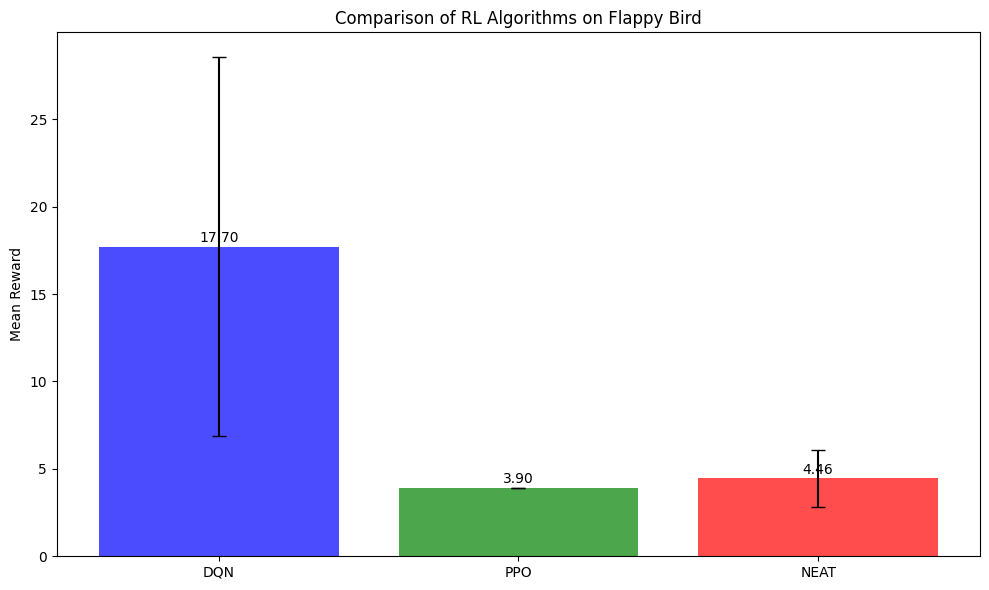


Graph saved as 'model_comparison.png'


In [9]:
from compare_models import evaluate_unified_models

print("🎮 Pokrećem testiranje modela na Flappy Bird...")
print("Svaki algoritam će igrati 10 partija")
print("=" * 50)

results = evaluate_unified_models(num_episodes=10)

## 5. Zaključak

### Ključni Nalazi:

1. **DQN** pokazuje najbolje performance, ali je **nestabilan**

2. **NEAT** je **stabilniji od DQN**, ali i **slabiji**

3. **PPO** je **najstabilniji**, ali i **najslabiji** u ovom eksperimentu - verovatno zbog nedovoljnog treniranja
    
4. **Trade-off između performance i stabilnosti** je očigledan - DQN ima visoke ali nestabilne rezultate, NEAT i PPO imaju niske ali stabilne